In [1]:
import urllib.request

url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

for f in files:
    urllib.request.urlretrieve(url + f, f)

Epoch 1, Train Acc: 0.7890, Val Acc: 0.8273
Epoch 2, Train Acc: 0.8402, Val Acc: 0.8778
Epoch 3, Train Acc: 0.8569, Val Acc: 0.8908
Epoch 4, Train Acc: 0.8673, Val Acc: 0.8983
Epoch 5, Train Acc: 0.8735, Val Acc: 0.9032
Epoch 6, Train Acc: 0.8788, Val Acc: 0.9063
Epoch 7, Train Acc: 0.8835, Val Acc: 0.9092
Epoch 8, Train Acc: 0.8869, Val Acc: 0.9128
Epoch 9, Train Acc: 0.8908, Val Acc: 0.9142
Epoch 10, Train Acc: 0.8936, Val Acc: 0.9150
Epoch 11, Train Acc: 0.8955, Val Acc: 0.9167
Epoch 12, Train Acc: 0.8973, Val Acc: 0.9187
Epoch 13, Train Acc: 0.8993, Val Acc: 0.9203
Epoch 14, Train Acc: 0.9005, Val Acc: 0.9220
Epoch 15, Train Acc: 0.9018, Val Acc: 0.9235


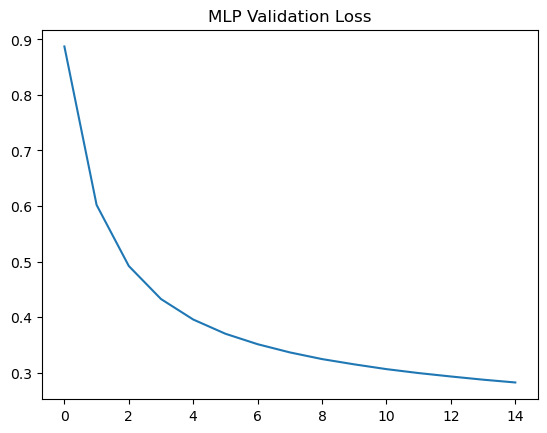

AE Epoch 1, Loss: 0.6947
AE Epoch 2, Loss: 0.6673
AE Epoch 3, Loss: 0.6412
AE Epoch 4, Loss: 0.6141
AE Epoch 5, Loss: 0.5851
AE Epoch 6, Loss: 0.5542
AE Epoch 7, Loss: 0.5224
AE Epoch 8, Loss: 0.4915
AE Epoch 9, Loss: 0.4630
AE Epoch 10, Loss: 0.4379


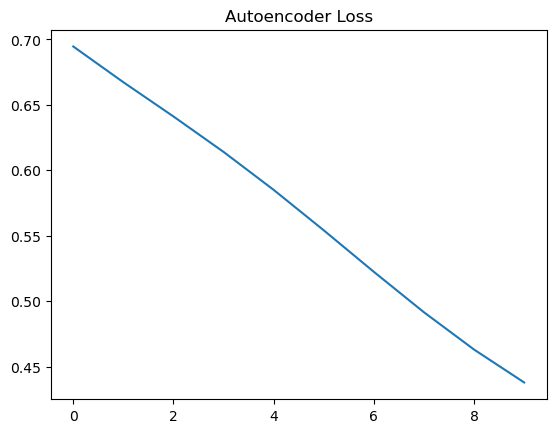

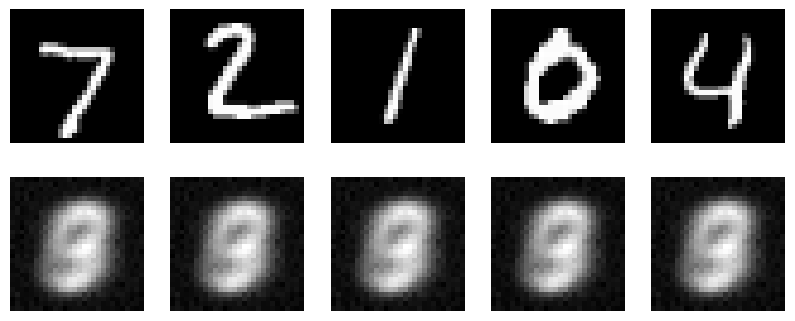

RBM Epoch 1, Error: 0.4815
RBM Epoch 2, Error: 0.4679
RBM Epoch 3, Error: 0.4594
RBM Epoch 4, Error: 0.4526
RBM Epoch 5, Error: 0.4461


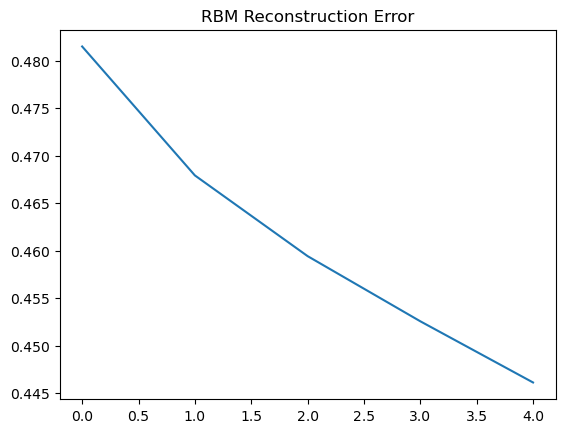


Outlier Detection Results
Threshold: 0.1200152597090428
Number of outliers detected: 467


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gzip

np.random.seed(42)


# LOAD MNIST (FROM DOWNLOADED FILES)
# =====================================================

def load_mnist_local():
    with gzip.open("train-images-idx3-ubyte.gz", 'rb') as f:
        X_train = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 784)/255.0

    with gzip.open("train-labels-idx1-ubyte.gz", 'rb') as f:
        y_train = np.frombuffer(f.read(), np.uint8, offset=8)

    with gzip.open("t10k-images-idx3-ubyte.gz", 'rb') as f:
        X_test = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 784)/255.0

    with gzip.open("t10k-labels-idx1-ubyte.gz", 'rb') as f:
        y_test = np.frombuffer(f.read(), np.uint8, offset=8)

    return X_train, y_train, X_test, y_test



# ACTIVATIONS
# =====================================================

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s*(1-s)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)



# LOSS
# =====================================================

def cross_entropy(pred, y):
    m = y.shape[0]
    y_onehot = np.zeros((m, pred.shape[1]))
    y_onehot[np.arange(m), y] = 1
    return -np.sum(y_onehot * np.log(pred + 1e-9)) / m



# 2-LAYER MLP
# =====================================================

class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2/input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2/hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.tanh(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.out = softmax(self.z2)
        return self.out

    def backward(self, X, y, lr):
        m = X.shape[0]

        grad_z2 = self.out.copy()
        grad_z2[np.arange(m), y] -= 1
        grad_z2 /= m

        dW2 = self.a1.T @ grad_z2
        db2 = np.sum(grad_z2, axis=0, keepdims=True)

        grad_a1 = grad_z2 @ self.W2.T
        grad_z1 = grad_a1 * (1 - np.tanh(self.z1)**2)

        dW1 = X.T @ grad_z1
        db1 = np.sum(grad_z1, axis=0, keepdims=True)

        self.W1 -= lr*dW1
        self.b1 -= lr*db1
        self.W2 -= lr*dW2
        self.b2 -= lr*db2


def train_mlp(model, X, y, X_val, y_val, epochs=10, lr=0.01, batch_size=64):
    losses, accs = [], []

    for epoch in range(epochs):
        idx = np.random.permutation(len(X))
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        for start in range(0, len(X_shuffled), batch_size):
            end = start + batch_size
            xb = X_shuffled[start:end]
            yb = y_shuffled[start:end]
            model.forward(xb)
            model.backward(xb, yb, lr)

        train_preds = model.forward(X)
        train_loss = cross_entropy(train_preds, y)
        train_acc = np.mean(np.argmax(train_preds, axis=1) == y)

        val_preds = model.forward(X_val)
        val_loss = cross_entropy(val_preds, y_val)
        val_acc = np.mean(np.argmax(val_preds, axis=1) == y_val)

        losses.append(val_loss)
        accs.append(val_acc)

        print(f"Epoch {epoch+1}, "
              f"Train Acc: {train_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}")

    return losses, accs



# AUTOENCODER
# =====================================================

class Autoencoder:
    def __init__(self, input_dim, latent_dim):
        self.W1 = np.random.randn(input_dim, latent_dim)*0.01
        self.b1 = np.zeros((1, latent_dim))
        self.W2 = np.random.randn(latent_dim, input_dim)*0.01
        self.b2 = np.zeros((1, input_dim))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.latent = sigmoid(self.z1)
        self.z2 = self.latent @ self.W2 + self.b2
        self.out = sigmoid(self.z2)
        return self.out

    def train(self, X, epochs=10, lr=0.01, sparse=False, l1=1e-3):
        losses = []
        m = X.shape[0]

        for epoch in range(epochs):
            recon = self.forward(X)

            loss = -np.mean(X*np.log(recon+1e-9) + (1-X)*np.log(1-recon+1e-9))
            if sparse:
                loss += l1*np.mean(np.abs(self.latent))

            losses.append(loss)

            d_out = (recon - X) / m

            dW2 = self.latent.T @ d_out
            db2 = np.sum(d_out, axis=0, keepdims=True)

            d_latent = d_out @ self.W2.T * sigmoid_deriv(self.z1)
            if sparse:
                d_latent += l1*np.sign(self.latent) / m

            dW1 = X.T @ d_latent
            db1 = np.sum(d_latent, axis=0, keepdims=True)

            self.W1 -= lr*dW1
            self.b1 -= lr*db1
            self.W2 -= lr*dW2
            self.b2 -= lr*db2

            print(f"AE Epoch {epoch+1}, Loss: {loss:.4f}")

        return losses



# RBM
# =====================================================

class RBM:
    def __init__(self, visible, hidden):
        self.W = np.random.randn(visible, hidden)*0.01
        self.hb = np.zeros(hidden)
        self.vb = np.zeros(visible)

    def sample_h(self, v):
        p = sigmoid(v @ self.W + self.hb)
        return p, (p > np.random.rand(*p.shape)).astype(float)

    def sample_v(self, h):
        p = sigmoid(h @ self.W.T + self.vb)
        return p, (p > np.random.rand(*p.shape)).astype(float)

    def train(self, X, epochs=5, lr=0.01, k=1):
        errors = []
        m = X.shape[0]

        for epoch in range(epochs):
            ph0, _ = self.sample_h(X)

            v = X.copy()
            for _ in range(k):
                _, h = self.sample_h(v)
                _, v = self.sample_v(h)

            phk, _ = self.sample_h(v)

            self.W += lr * ((X.T @ ph0 - v.T @ phk) / m)
            self.vb += lr * np.mean(X - v, axis=0)
            self.hb += lr * np.mean(ph0 - phk, axis=0)

            error = np.mean((X - v)**2)
            errors.append(error)

            print(f"RBM Epoch {epoch+1}, Error: {error:.4f}")

        return errors



# HYPERPARAMETERS
# =====================================================

mlp_hidden_size = 128
mlp_learning_rate = 0.005
mlp_batch_size = 128
mlp_epochs = 15

ae_latent_dim = 64
ae_learning_rate = 0.01
ae_epochs = 10
ae_l1_penalty = 1e-3

rbm_hidden_units = 64
rbm_learning_rate = 0.01
rbm_epochs = 5


# =====================================================
# MAIN
# =====================================================

X_train, y_train, X_test, y_test = load_mnist_local()

split = int(0.9 * len(X_train))
X_val = X_train[split:]
y_val = y_train[split:]
X_train = X_train[:split]
y_train = y_train[:split]

# ---- MLP ----
mlp = MLP(784, mlp_hidden_size, 10)
losses, accs = train_mlp(
    mlp,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=mlp_epochs,
    lr=mlp_learning_rate,
    batch_size=mlp_batch_size
)

plt.plot(losses)
plt.title("MLP Validation Loss")
plt.show()

# ---- AUTOENCODER ----
ae = Autoencoder(784, ae_latent_dim)
ae_losses = ae.train(
    X_train[:5000],
    epochs=ae_epochs,
    lr=ae_learning_rate,
    sparse=True,
    l1=ae_l1_penalty
)

plt.plot(ae_losses)
plt.title("Autoencoder Loss")
plt.show()

# Reconstruction
recon = ae.forward(X_test[:5])

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

# ---- RBM ----
rbm = RBM(784, rbm_hidden_units)
rbm_errors = rbm.train(
    X_train[:5000],
    epochs=rbm_epochs,
    lr=rbm_learning_rate,
    k=1
)

plt.plot(rbm_errors)
plt.title("RBM Reconstruction Error")
plt.show()

# =====================================================
# OUTLIER DETECTION
# =====================================================

recon_test = ae.forward(X_test)
recon_error = np.mean((X_test - recon_test)**2, axis=1)

threshold = np.mean(recon_error) + 2*np.std(recon_error)
outliers = np.where(recon_error > threshold)[0]

print("\nOutlier Detection Results")
print("Threshold:", threshold)
print("Number of outliers detected:", len(outliers))